<a href="https://colab.research.google.com/github/AlejoCNYT/econometrics-notebooks/blob/main/LinearRegression-Training_Exercise_1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Game,Year,WinMen,WinWomen
0,1,1948,10.3,11.9
1,2,1952,10.4,11.5
2,3,1956,10.5,11.5
3,4,1960,10.2,11.0
4,5,1964,10.0,11.4


--- Ecuaciones del Modelo Lineal ---
Hombres: Tiempo = 28.8540 + (-0.0095 * Año)
Mujeres: Tiempo = 42.1894 + (-0.0157 * Año)

(a) Año proyectado de igualdad de tiempos (Lineal): 2140
(c) Tiempo proyectado en ese punto de igualdad: 8.53 segundos
--- Ecuaciones del Modelo Log-Lineal ---
Hombres: ln(Tiempo) = 4.1660 + (-0.0009 * Año)
Mujeres: ln(Tiempo) = 5.1795 + (-0.0014 * Año)

(b) Año proyectado de igualdad de tiempos (No Lineal): 2183


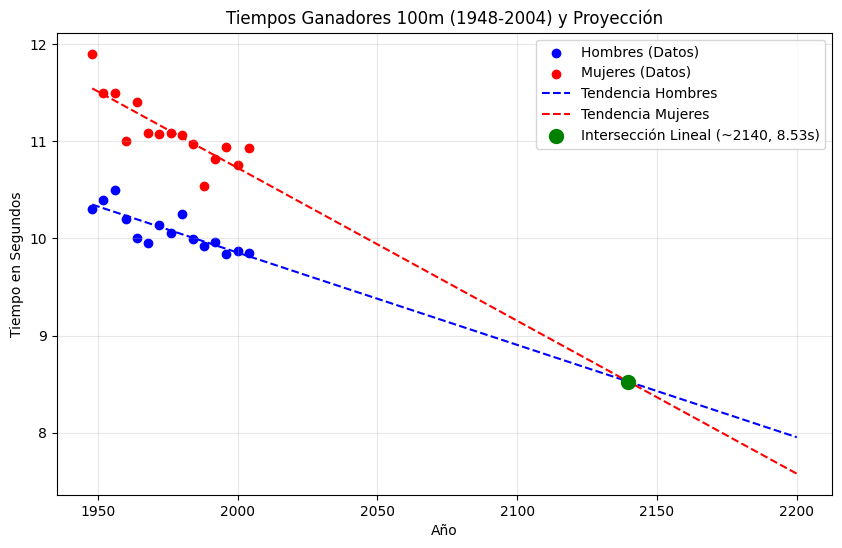


(d) Comentarios sobre los resultados y modelos:
1. Limitaciones Físicas: Ambos modelos predicen que los tiempos continuarán bajando indefinidamente, 
   llegando a ~8.53s. Biomecánicamente, existe un límite humano que los modelos de regresión simples 
   ignoran por completo.
2. Cambio Estructural: La pendiente más pronunciada en mujeres se debe a un 'catch-up' histórico 
   (profesionalización, mejores técnicas de entrenamiento implementadas más tarde que en hombres). 
   Extrapolar esta tasa de mejora hacia el siglo XXII asume erróneamente que las mujeres siempre 
   mejorarán más rápido que los hombres, lo cual sesga el punto de intersección.



In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. PREPARACIÓN DE DATOS
# Game = Número del juego olímpico (1 a 15)
# Year = Año del juego (1948 a 2004)
# WinMen = Tiempo ganador en hombres en segundos
# WinWomen = Tiempo ganador en mujeres en segundos

data = {
    'Game': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'Year': [1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004],
    'WinMen': [10.30, 10.40, 10.50, 10.20, 10.00, 9.95, 10.14, 10.06, 10.25, 9.99, 9.92, 9.96, 9.84, 9.87, 9.85],
    'WinWomen': [11.90, 11.50, 11.50, 11.00, 11.40, 11.08, 11.07, 11.08, 11.06, 10.97, 10.54, 10.82, 10.94, 10.75, 10.93]
}

df = pd.DataFrame(data)

# Mostrar los datos para confirmar
display(df.head())

# 2. MODELO DE TENDENCIA LINEAL (Preguntas A y C)

# Añadir la constante para el modelo de regresión (intercepto)
X = sm.add_constant(df['Year'])

# Ajustar los modelos por Mínimos Cuadrados Ordinarios (OLS)
model_men_lin = sm.OLS(df['WinMen'], X).fit()
model_women_lin = sm.OLS(df['WinWomen'], X).fit()

# Extraer los parámetros (alpha = intercepto, beta = pendiente)
alpha_m, beta_m = model_men_lin.params
alpha_w, beta_w = model_women_lin.params

print("--- Ecuaciones del Modelo Lineal ---")
print(f"Hombres: Tiempo = {alpha_m:.4f} + ({beta_m:.4f} * Año)")
print(f"Mujeres: Tiempo = {alpha_w:.4f} + ({beta_w:.4f} * Año)")

# Igualar las ecuaciones para encontrar el Año (Pregunta A)
# alpha_m + beta_m * Year = alpha_w + beta_w * Year
year_equal_lin = (alpha_w - alpha_m) / (beta_m - beta_w)

# Calcular el tiempo ganador en ese año (Pregunta C)
time_equal_lin = alpha_m + beta_m * year_equal_lin

print(f"\n(a) Año proyectado de igualdad de tiempos (Lineal): {year_equal_lin:.0f}")
print(f"(c) Tiempo proyectado en ese punto de igualdad: {time_equal_lin:.2f} segundos")
# 3. MODELO DE TENDENCIA NO LINEAL (Pregunta B)

# Crear las variables logarítmicas
df['LogWinMen'] = np.log(df['WinMen'])
df['LogWinWomen'] = np.log(df['WinWomen'])

# Ajustar los modelos OLS con la variable logarítmica
model_men_log = sm.OLS(df['LogWinMen'], X).fit()
model_women_log = sm.OLS(df['LogWinWomen'], X).fit()

# Extraer parámetros
alpha_m_log, beta_m_log = model_men_log.params
alpha_w_log, beta_w_log = model_women_log.params

print("--- Ecuaciones del Modelo Log-Lineal ---")
print(f"Hombres: ln(Tiempo) = {alpha_m_log:.4f} + ({beta_m_log:.4f} * Año)")
print(f"Mujeres: ln(Tiempo) = {alpha_w_log:.4f} + ({beta_w_log:.4f} * Año)")

# Calcular el año de intersección para el modelo log-lineal
year_equal_log = (alpha_w_log - alpha_m_log) / (beta_m_log - beta_w_log)

print(f"\n(b) Año proyectado de igualdad de tiempos (No Lineal): {year_equal_log:.0f}")
# 4. VISUALIZACIÓN Y ANÁLISIS (Pregunta D)

plt.figure(figsize=(10, 6))

# Puntos de datos históricos
plt.scatter(df['Year'], df['WinMen'], color='blue', label='Hombres (Datos)')
plt.scatter(df['Year'], df['WinWomen'], color='red', label='Mujeres (Datos)')

# Años futuros para la proyección en la gráfica (hasta 2200)
future_years = np.arange(1948, 2201)

# Calcular proyecciones del modelo lineal
pred_men_lin = alpha_m + beta_m * future_years
pred_women_lin = alpha_w + beta_w * future_years

# Trazar líneas de tendencia
plt.plot(future_years, pred_men_lin, 'b--', label='Tendencia Hombres')
plt.plot(future_years, pred_women_lin, 'r--', label='Tendencia Mujeres')

# Marcar el punto de intersección
plt.scatter(year_equal_lin, time_equal_lin, color='green', zorder=5, s=100,
            label=f'Intersección Lineal (~{year_equal_lin:.0f}, {time_equal_lin:.2f}s)')

# Configuraciones del gráfico
plt.title('Tiempos Ganadores 100m (1948-2004) y Proyección')
plt.xlabel('Año')
plt.ylabel('Tiempo en Segundos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comentario para la pregunta D
print("""
(d) Comentarios sobre los resultados y modelos:
1. Limitaciones Físicas: Ambos modelos predicen que los tiempos continuarán bajando indefinidamente,
   llegando a ~8.53s. Biomecánicamente, existe un límite humano que los modelos de regresión simples
   ignoran por completo.
2. Cambio Estructural: La pendiente más pronunciada en mujeres se debe a un 'catch-up' histórico
   (profesionalización, mejores técnicas de entrenamiento implementadas más tarde que en hombres).
   Extrapolar esta tasa de mejora hacia el siglo XXII asume erróneamente que las mujeres siempre
   mejorarán más rápido que los hombres, lo cual sesga el punto de intersección.
""")